In [149]:
# import dependencies
import pandas as pd
import os
import plotly.express as px

In [133]:
# Load file
diet_df = pd.read_csv('Resources/FAO_CAHD.csv')
diet_df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,FAO_CAHD_7005,Percentage of the population unable to afford ...,_T,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,FAO_CAHD_7005,Percentage of the population unable to afford ...,_T,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,FAO_CAHD_7005,Percentage of the population unable to afford ...,_T,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,FAO_CAHD_7005,Percentage of the population unable to afford ...,_T,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,FAO_CAHD_7005,Percentage of the population unable to afford ...,_T,...,0,Units,RATIO,Ratio,602,CCYY,A,Normal value,PU,Public


In [134]:
# Check shape of diet_df
diet_df.shape

(2324, 37)

In [135]:
# Look at columns and unique entries
unique_count = diet_df.nunique()
unique_count

STRUCTURE                   1
STRUCTURE_ID                1
ACTION                      1
FREQ                        1
FREQ_LABEL                  1
REF_AREA                  153
REF_AREA_LABEL            153
INDICATOR                   2
INDICATOR_LABEL             2
SEX                         1
SEX_LABEL                   1
AGE                         1
AGE_LABEL                   1
URBANISATION                1
URBANISATION_LABEL          1
UNIT_MEASURE                2
UNIT_MEASURE_LABEL          2
COMP_BREAKDOWN_1            1
COMP_BREAKDOWN_1_LABEL      1
COMP_BREAKDOWN_2            1
COMP_BREAKDOWN_2_LABEL      1
COMP_BREAKDOWN_3            1
COMP_BREAKDOWN_3_LABEL      1
TIME_PERIOD                 8
OBS_VALUE                 695
DATABASE_ID                 1
DATABASE_ID_LABEL           1
UNIT_MULT                   2
UNIT_MULT_LABEL             2
UNIT_TYPE                   2
UNIT_TYPE_LABEL             2
TIME_FORMAT                 1
TIME_FORMAT_LABEL           1
OBS_STATUS

In [136]:
# Create a new df with pared down columns
diet_df = diet_df[['REF_AREA_LABEL', 'UNIT_MEASURE_LABEL', 'UNIT_MULT', 'TIME_PERIOD', 'OBS_VALUE']]
diet_df.head()

,REF_AREA_LABEL,UNIT_MEASURE_LABEL,UNIT_MULT,TIME_PERIOD,OBS_VALUE
0,Albania,Percentage,0,2017,24.3
1,Albania,Percentage,0,2018,17.6
2,Albania,Percentage,0,2019,14.6
3,Albania,Percentage,0,2020,13.9
4,Albania,Percentage,0,2021,12.6


In [137]:
# Check REF_AREA_LABEL uniques
diet_df['REF_AREA_LABEL'].unique()

array(['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bangladesh', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'Taiwan, China',
       'China', 'Colombia', 'Comoros', 'Congo, Rep.', 'Costa Rica',
       'Croatia', 'Cyprus', 'Czechia', "Cote d'Ivoire",
       'Congo, Dem. Rep.', 'Denmark', 'Djibouti', 'Dominican Republic',
       'Ecuador', 'Egypt, Arab Rep.', 'Estonia', 'Eswatini', 'Ethiopia',
       'Fiji', 'Finland', 'France', 'Gabon', 'Gambia, The', 'Germany',
       'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea-Bissau',
       'Guinea', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Iceland',
       'India', 'Indonesia', 'Iran, Islamic Rep.', 'Iraq', 'Ireland',
       'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 

In [138]:
# Use only Canada and United States rows
diet_df = diet_df[diet_df['REF_AREA_LABEL'].isin(["Canada", "United States"])]

diet_df.head()

,REF_AREA_LABEL,UNIT_MEASURE_LABEL,UNIT_MULT,TIME_PERIOD,OBS_VALUE
133,Canada,Percentage,0,2017,3.2
134,Canada,Percentage,0,2018,2.7
135,Canada,Percentage,0,2019,2.7
136,Canada,Percentage,0,2020,3.2
137,Canada,Percentage,0,2021,3.0


In [139]:
# Check range of years in TIME_PERIOD
diet_df['TIME_PERIOD'].unique()

array([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype=int64)

OK, this dataset only has data from 2017 to 2024. Our other datasets go back to 1908. Let's check to see if 1908 data is available.

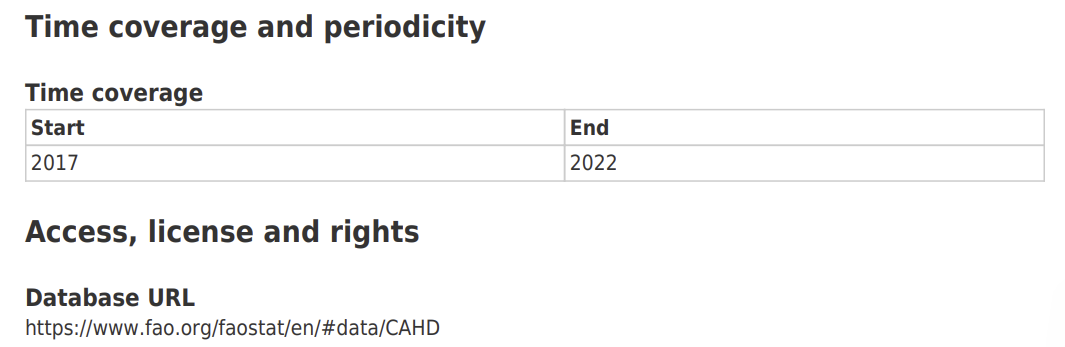

This dataset starts at 2017, as seen above (from dataset Metadata page).

In [140]:
# Remove 2024 data from diet_df
diet_df = diet_df[diet_df['TIME_PERIOD'] <= 2023]

diet_df.head()

,REF_AREA_LABEL,UNIT_MEASURE_LABEL,UNIT_MULT,TIME_PERIOD,OBS_VALUE
133,Canada,Percentage,0,2017,3.2
134,Canada,Percentage,0,2018,2.7
135,Canada,Percentage,0,2019,2.7
136,Canada,Percentage,0,2020,3.2
137,Canada,Percentage,0,2021,3.0


In [141]:
# Check UNIT_MEASUREMENT_LABEL column
diet_df['UNIT_MEASURE_LABEL'].unique()

array(['Percentage', 'Persons'], dtype=object)

In [142]:
# Check UNIT_MEASUREMENT_LABEL column
diet_df['UNIT_MEASURE_LABEL'].value_counts()

UNIT_MEASURE_LABEL
Percentage    14
Persons       14
Name: count, dtype: int64

Let's split this DataFrame into two: one for Percentage and one for Persons.

In [143]:
# Subset where unit is Percentage
diet_percentage_df = diet_df[diet_df["UNIT_MEASURE_LABEL"] == "Percentage"].copy()

# Subset where unit is Persons
diet_persons_df = diet_df[diet_df["UNIT_MEASURE_LABEL"] == "Persons"].copy()


In [144]:
# View entire df
diet_persons_df

,REF_AREA_LABEL,UNIT_MEASURE_LABEL,UNIT_MULT,TIME_PERIOD,OBS_VALUE
1334,Canada,Persons,6,2017,1.2
1335,Canada,Persons,6,2018,1.0
1336,Canada,Persons,6,2019,1.0
1337,Canada,Persons,6,2020,1.2
1338,Canada,Persons,6,2021,1.2
1339,Canada,Persons,6,2022,1.1
2015,United States,Persons,6,2017,16.6
2016,United States,Persons,6,2018,15.9
2017,United States,Persons,6,2019,14.4
2018,United States,Persons,6,2020,11.0


This is where UNIT_MULT comes into play, it means 10^6 or multitply by 1 million (Example: 1.2 OBS_VALUE = 1,200,000)

In [145]:
# Rename columns
diet_persons_df = diet_persons_df.rename(columns={
    "REF_AREA_LABEL": "Country",
    "UNIT_MEASURE_LABEL": "Unit of Measure",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "Total (million)"
})

diet_persons_df

,Country,Unit of Measure,UNIT_MULT,Year,Total (million)
1334,Canada,Persons,6,2017,1.2
1335,Canada,Persons,6,2018,1.0
1336,Canada,Persons,6,2019,1.0
1337,Canada,Persons,6,2020,1.2
1338,Canada,Persons,6,2021,1.2
1339,Canada,Persons,6,2022,1.1
2015,United States,Persons,6,2017,16.6
2016,United States,Persons,6,2018,15.9
2017,United States,Persons,6,2019,14.4
2018,United States,Persons,6,2020,11.0


In [146]:
# Drop UNIT_MULT column
diet_persons_df = diet_persons_df.drop(columns="UNIT_MULT")

diet_persons_df

,Country,Unit of Measure,Year,Total (million)
1334,Canada,Persons,2017,1.2
1335,Canada,Persons,2018,1.0
1336,Canada,Persons,2019,1.0
1337,Canada,Persons,2020,1.2
1338,Canada,Persons,2021,1.2
1339,Canada,Persons,2022,1.1
2015,United States,Persons,2017,16.6
2016,United States,Persons,2018,15.9
2017,United States,Persons,2019,14.4
2018,United States,Persons,2020,11.0


In [147]:
# Sort diet_persons_df
diet_persons_df = diet_persons_df.sort_values(
    by=['Year', 'Country'],
    ascending=[False, True],
).reset_index(drop=True)

diet_persons_df

,Country,Unit of Measure,Year,Total (million)
0,Canada,Persons,2023,1.2
1,United States,Persons,2023,16.3
2,Canada,Persons,2022,1.1
3,United States,Persons,2022,16.2
4,Canada,Persons,2021,1.2
5,United States,Persons,2021,8.5
6,Canada,Persons,2020,1.2
7,United States,Persons,2020,11.0
8,Canada,Persons,2019,1.0
9,United States,Persons,2019,14.4


Let's do the same for the diet_percentage_df, maybe in a single block of code.

In [148]:
# Rename columns
diet_percentage_df = diet_percentage_df.rename(columns={
    "REF_AREA_LABEL": "Country",
    "UNIT_MEASURE_LABEL": "Unit of Measure",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "Percentage"
})

diet_percentage_df = diet_percentage_df.drop(columns="UNIT_MULT")

# Sort diet_percentage_df
diet_percentage_df = diet_percentage_df.sort_values(
    by=['Year', 'Country'],
    ascending=[False, True],
).reset_index(drop=True)

diet_percentage_df

,Country,Unit of Measure,Year,Percentage
0,Canada,Percentage,2023,3.0
1,United States,Percentage,2023,4.7
2,Canada,Percentage,2022,2.7
3,United States,Percentage,2022,4.7
4,Canada,Percentage,2021,3.0
5,United States,Percentage,2021,2.5
6,Canada,Percentage,2020,3.2
7,United States,Percentage,2020,3.2
8,Canada,Percentage,2019,2.7
9,United States,Percentage,2019,4.2


In [154]:
# Line plot of diet_percentage_df
fig = px.line(
    diet_percentage_df,
    x="Year",
    y="Percentage",
    color="Country",
    markers=True,        # show markers for each data point
    title="Percentage of Population Unable to Afford a Healthy Diet in North America"
)

fig.show()

In [153]:
# Line plot of diet_persons_df
fig = px.line(
    diet_persons_df,
    x="Year",
    y="Total (million)",
    color="Country",
    markers=True,        # show markers for each data point
    title="Total Persons (by million) Unable to Afford a Healthy Diet in North America"
)

fig.show()

The short time frame doesn't show a lot of trends, although 2021 marked a peak for affordability. 2022 saw a return to previous highs. Trump presidency from 2017-2021, COVID starting in 2020, could be among factors.